# AI Agent

In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from typing import TypedDict, Dict, Optional, Annotated,Literal

In [3]:
import yfinance as yf
from langchain.tools import tool

@tool
def get_price( ticker: str ):
    """
    Get the latest closing price for a stock.

    Args:
        ticker: Stock ticker symbol (e.g., "AAPL", "TSLA")

    Returns:
        A dictionary containing:
        - ticker: Stock symbol
        - price: Latest closing price
        - currency: Trading currency

    Raises:
        ValueError: If the ticker is invalid or data is unavailable
    """

    stock = yf.Ticker(ticker)
    data = stock.history(period="1d")

    if data.empty:
        return {"error": "Invalid ticker or no data"}

    return {
        "ticker": ticker,
        "price": float(data["Close"].iloc[-1])
    }


In [4]:
@tool
def get_summary( ticker: str):
    """
    Get a basic summary of a stock using Yahoo Finance.

    Args:
        ticker (str): Stock ticker symbol (e.g., "AAPL", "MSFT").

    Returns:
        dict: A dictionary containing:
            - ticker: The stock ticker symbol
            - name: Company short name
            - sector: Business sector
            - market_cap: Market capitalization value
            - currency: Trading currency
    """
    stock = yf.Ticker(ticker)
    info = stock.info

    return {
        "ticker": ticker,
        "name": info.get("shortName"),
        "sector": info.get("sector"),
        "market_cap": info.get("marketCap"),
        "currency": info.get("currency")
    }


In [5]:
@tool
def get_history( ticker: str, period="5d"):
    """
    Get historical price data for a stock using Yahoo Finance.

    Args:
        ticker (str): Stock ticker symbol (e.g., "AAPL", "TSLA").
        period (str): Time period for historical data 
                      (e.g., "1d", "5d", "1mo", "6mo", "1y").

    Returns:
        dict: If data exists, returns a dictionary containing:
            - Open: Opening prices
            - High: Highest prices
            - Low: Lowest prices
            - Close: Closing prices
            - Volume: Trading volume
        dict: If no data is available, returns:
            - error: Error message string
    """
    stock = yf.Ticker(ticker)
    hist = stock.history(period=period)

    if hist.empty:
        return {"error": "No historical data"}

    return hist[["Open", "High", "Low", "Close", "Volume"]].to_dict()


In [6]:
from dotenv import load_dotenv
import os

load_dotenv()

# Initialize the Groq LLM
llm = ChatGroq(
    temperature=0,
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model_name="openai/gpt-oss-20b"
)

response = llm.invoke( "Genrate 4 ideas about space" )
response.content

'Here are four fresh, cross‑disciplinary ideas that revolve around space—each with a clear hook and a quick “next‑step” suggestion:\n\n| # | Idea | What it’s about | Why it’s cool | Quick next step |\n|---|------|-----------------|---------------|-----------------|\n| 1 | **“Orbit‑to‑Orbit” Modular Habitat** | A stackable, inflatable habitat that can be launched as a single unit and then assembled in orbit into a larger, multi‑module living space. | Solves the cost‑prohibitively high mass of traditional launch‑by‑launch modules; each module can be swapped or upgraded. | Prototype a 1‑m³ inflatable module and test its structural integrity in a parabolic flight. |\n| 2 | **Deep‑Space Time‑Dilation Story** | A narrative set on a generation ship traveling at 0.99\u202fc, where the crew experiences 10\u202fyears while 100\u202fyears pass on Earth. The plot follows the psychological and cultural evolution of the ship’s society. | Combines hard‑science relativity with rich character drama; of

In [7]:
tools = [ get_price , get_summary , get_history ]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools( tools )

In [8]:
response = llm_with_tools.invoke( "Get stoke of Tesla?" )
print(response)

content='' additional_kwargs={'reasoning_content': 'User: "Get stoke of Tesla?" Likely typo: "Get stock of Tesla?" They want stock info. We can provide summary and price. Use get_summary and get_price.', 'tool_calls': [{'id': 'fc_c6ee419b-32fc-4a3a-b73f-7157862b5eda', 'function': {'arguments': '{"ticker":"TSLA"}', 'name': 'get_summary'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 483, 'total_tokens': 546, 'completion_time': 0.064646042, 'prompt_time': 0.027331056, 'queue_time': 0.04263897, 'total_time': 0.091977098, 'completion_tokens_details': {'reasoning_tokens': 39}}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_feb9b278f1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019ba9f0-9ff5-7902-a6ff-3fddf0243781-0' tool_calls=[{'name': 'get_summary', 'args': {'ticker': 'TSLA'}, 'id': 'fc_c6ee419b-32fc-4a3a-b73f-7157862b5eda', 'type': 'tool_call'}] usage_metadata={'input_tok

In [9]:
response.tool_calls

[{'name': 'get_summary',
  'args': {'ticker': 'TSLA'},
  'id': 'fc_c6ee419b-32fc-4a3a-b73f-7157862b5eda',
  'type': 'tool_call'}]

### Sate Graph

In [10]:
class ChatbotState(TypedDict):
    message  : Annotated[list, add_messages]
    response  : str

### Chatbot node

In [11]:
def chatbot_node( state:ChatbotState ) -> Dict:
        
    response = llm_with_tools.invoke( state['message'] )

    return {
        'message'  : response,
        'response' : response.content
    }

## Tool node

In [12]:
from langchain_core.messages import ToolMessage

def tool_node(state: ChatbotState) -> Dict:
    
    results = []

    for tool_call in state['message'][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        result = tool.invoke( tool_call['args'] )
        results.append(ToolMessage(content=result, tool_call_id=tool_call["id"]))

    return {"message": results}    


## route

In [13]:
def should_continue(state: ChatbotState) -> Literal["tool_node", END]:

    last_message = state['message'][-1]
    print(last_message)

    if last_message.tool_calls:
        return "tool_node"
    
    return END


In [14]:
graph = StateGraph(ChatbotState)

graph.add_node("chatbot_node", chatbot_node)
graph.add_node("tool_node", tool_node)

In [15]:
graph.add_edge(START, "chatbot_node")
graph.add_conditional_edges("chatbot_node", should_continue )
graph.add_edge("tool_node", "chatbot_node")

checkpointer = InMemorySaver()
graph = graph.compile( checkpointer=checkpointer )

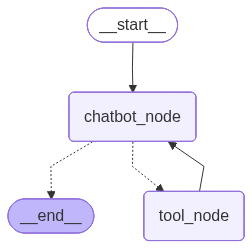

In [16]:
from IPython.display import Image, display

png_data = graph.get_graph().draw_mermaid_png()
display(Image(data=png_data))

In [23]:
result = graph.invoke(

                {
                    "message" : "What the price stock for tesla?" 
                },

                { "configurable": {"thread_id": "1"} },

    )

content='' additional_kwargs={'reasoning_content': 'We need to call get_price function with ticker "TSLA".', 'tool_calls': [{'id': 'fc_39f9838a-ea5d-4d31-9be0-c3915141d4c0', 'function': {'arguments': '{"ticker":"TSLA"}', 'name': 'get_price'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 534, 'total_tokens': 572, 'completion_time': 0.039612121, 'prompt_time': 0.002821587, 'queue_time': 0.042976345, 'total_time': 0.042433708, 'prompt_tokens_details': {'cached_tokens': 512}, 'completion_tokens_details': {'reasoning_tokens': 14}}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e189667b30', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019ba9f1-63b7-7993-b363-86807fa5acf4-0' tool_calls=[{'name': 'get_price', 'args': {'ticker': 'TSLA'}, 'id': 'fc_39f9838a-ea5d-4d31-9be0-c3915141d4c0', 'type': 'tool_call'}] usage_metadata={'input_tokens': 534, 'output_tokens': 38, 'total_tokens': 5

In [24]:
result

{'message': [HumanMessage(content='My name is mohammed', additional_kwargs={}, response_metadata={}, id='a18ba820-3de6-41a9-bdce-3fdcc74c83d5'),
  AIMessage(content='Nice to meet you, Mohammed! How can I help you today?', additional_kwargs={'reasoning_content': 'User says "My name is mohammed". Likely greeting. We can respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 483, 'total_tokens': 526, 'completion_time': 0.047428439, 'prompt_time': 0.023802956, 'queue_time': 0.042236337, 'total_time': 0.071231395, 'completion_tokens_details': {'reasoning_tokens': 20}}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_eaf3c3bd86', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ba9f0-ed7f-7d60-bf2b-34d309a59e9c-0', usage_metadata={'input_tokens': 483, 'output_tokens': 43, 'total_tokens': 526}),
  HumanMessage(content='What is my name', additional_kwargs={}, response_metadata={}, id='76a06aaf-14f1-

In [25]:
print( result['message'][-1].content )

The latest closing price for Tesla (TSLA) is **$445.01**.
